#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

### Reading Assignment Answers

**1. Implications of "align before fuse" for my task**  
My task is to predict whether a speaker appears **Comfortable vs. Uncomfortable** from CMU-MOSEI videos using **visual frames** (faces/body) and **text** (transcripts). In this setting, alignment before fusion means (a) ensuring that visual and textual features correspond to the **same segment of speech** and (b) putting them into a **compatible representation space** (similar scales and semantics) before combining them. For my dataset, I likely need **segment-level alignment** (e.g., clip-level averages over frames and words for each labeled segment) and **feature-level normalization** (e.g., projected to same embedding dimension) so that the fusion module is not trying to “fix” timing or scale mismatches during training.

**2. Controlled experiments for fusion/alignment choices**  
I would design ablation studies where I vary **alignment quality** and **fusion strategy** while holding everything else fixed. For example: (a) compare models using misaligned pairs (shuffle text across videos) vs. correctly aligned pairs to quantify performance drop; (b) compare frame-level vs. segment-level visual alignment; (c) compare early fusion (concatenate embeddings) vs. late fusion (average logits) vs. tensor/low-rank fusion. I would also test alignment noise by jittering the temporal window used to average frames or words. Challenges include noisy timestamps in CMU-MOSEI, missing or corrupted videos, different sampling rates across modalities, and the fact that sentiment/comfort is weakly localized in time, which makes “ground truth” alignment ambiguous.

**3. Implications of the Platonic Representation Hypothesis**  
The Platonic Representation Hypothesis suggests that as models and data scale up, a **shared latent space** that captures underlying concepts (like comfort level) may emerge automatically across modalities. For my task, this would mean that a sufficiently large multimodal model trained on CMU-MOSEI-like data could learn a comfort/affect space where both visual and textual cues map to similar points without heavy manual alignment. In practice, my dataset is relatively small and domain-limited, so I should not assume that such a platonic representation will emerge “for free”; I still need explicit alignment choices (segmenting, feature normalization, contrastive objectives) to help the model learn good cross-modal structure.

**4. Why alignment might not emerge automatically**  
Automatic alignment can fail when: (a) **data is biased or imbalanced** (e.g., comfort strongly tied to specific topics or speakers); (b) modalities have **different noise patterns** (e.g., poor lighting vs. ASR errors) that the model overfits; (c) the model is **under-parameterized or under-trained** relative to task complexity; or (d) the training objective does not explicitly encourage cross-modal agreement (e.g., only optimizing unimodal losses). Follow-up work to the Platonic Representation paper highlights cases where scaling alone is not enough and where explicit **architectural inductive biases** or **contrastive/causal objectives** are needed to get robust alignment.

**5. Experiments to test emergence of alignment in my task**  
I would train several models with increasing capacity and data, and then probe whether visual and textual embeddings for the **same segment** are closer than for mismatched segments. Concretely, I can: (a) train a multimodal classifier without explicit contrastive loss, then measure cross-modal retrieval accuracy (text → video, video → text) using cosine similarity in the penultimate layer; (b) visualize embeddings with t-SNE/UMAP and check whether clusters correspond to comfort labels across modalities; and (c) compare models trained with vs. without an explicit contrastive term to see whether alignment emerges only when it is directly incentivized.

**6. Downsides of strong alignment and how to test for them**  
Overly strong or rigid alignment can **erase modality-specific information** (e.g., subtle visual cues or prosody that text lacks) and can **propagate spurious correlations** (e.g., sarcastic language misaligned with smiling faces). It may also encourage the model to ignore one modality if the other is easier to exploit. To test for these risks, I would: (a) run **modality ablations** (dropout or masking of text/vision) to check that each modality still contributes; (b) look for **counterfactual failures**, e.g., where visual comfort suggests “comfortable” but text is negative, and see how the model behaves; and (c) evaluate **calibration and robustness** under corrupted/perturbed inputs in just one modality. If performance collapses when one modality is mildly perturbed, it suggests over-reliance and potentially harmful alignment.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.t()

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.8324, 1.2209, 0.2128],
        [0.6512, 0.7969, 0.1304],
        [0.7316, 0.9867, 0.1673]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
# First squeeze to 1D then take dot product
d_prod = torch.einsum('i,i->', a.squeeze(), b.squeeze())

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A (uses square submatrix if A is not square)
min_dim = min(A.shape[0], A.shape[1])
diag = torch.einsum('ii->i', A[:min_dim, :min_dim])

# Outer Product of A and B
outer = torch.einsum('ij,kl->ikjl', A, B)

In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [6]:
# Use local MultiBench (no clone when running locally)
import sys
import os
# Notebook typically runs with cwd = hw1 (folder containing the notebook)
MULTIBENCH_ROOT = os.path.abspath(os.path.join(os.getcwd(), 'MultiBench'))
if MULTIBENCH_ROOT not in sys.path:
    sys.path.insert(0, MULTIBENCH_ROOT)
os.chdir(MULTIBENCH_ROOT)
print('MultiBench root:', MULTIBENCH_ROOT)

MultiBench root: /home/farandhigh-ubuntu/Documents/mmai/hw1/MultiBench


# Getting AV-MNIST dataset

In [7]:
import subprocess
import sys
import os
os.makedirs('data', exist_ok=True)
# Use python -m pip so it works in any venv
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown', 'memory_profiler'])
# torch/torchvision/torchtext already installed in env

0

In [8]:
# Download and extract AV-MNIST only if not already present
if not os.path.exists(os.path.join('avmnist', 'image', 'train_data.npy')):
    subprocess.check_call([sys.executable, '-m', 'gdown', '1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp'])
    subprocess.run(['tar', '-xvzf', 'avmnist.tar.gz'], check=True)
else:
    print('AV-MNIST data already present.')

AV-MNIST data already present.


In [9]:
# Path to the folder you untarred (works when run from MultiBench root)
data_dir = os.path.abspath('avmnist')

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

# Getting packages

In [10]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [11]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [12]:
import torch.nn.functional as F

class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [13]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
            with autocast(device_type=device_type):
                outputs = model(x)
                loss = criterion(outputs, y)

            if device.type == 'cuda':
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [14]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

Epoch 0: Train Loss: 2.1370 | Valid Acc: 36.06%


Epoch 1: Train Loss: 2.0397 | Valid Acc: 37.58%


Epoch 2: Train Loss: 2.0183 | Valid Acc: 39.10%


Epoch 3: Train Loss: 2.0031 | Valid Acc: 40.24%


Epoch 4: Train Loss: 1.9920 | Valid Acc: 40.08%

--- Final Evaluation Complete ---


Final Test Loss: 2.0191 | Test Accuracy: 40.73%


# Image:

In [15]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 1.1181 | Valid Acc: 67.42%


Epoch 1: Train Loss: 0.9486 | Valid Acc: 67.90%


Epoch 2: Train Loss: 0.9293 | Valid Acc: 68.38%


Epoch 3: Train Loss: 0.9186 | Valid Acc: 68.86%


Epoch 4: Train Loss: 0.9113 | Valid Acc: 68.86%

--- Final Evaluation Complete ---


Final Test Loss: 0.8970 | Test Accuracy: 64.37%


### Problem 3 Answers – Unimodal AV-MNIST

**1. Best performance and hyperparameters**  
For the **image model**, good performance is achieved with a small CNN and moderate regularization. One reasonable configuration is:
- Optimizer: Adam, learning rate = 1e-3, weight decay = 1e-3  
- Epochs: 10–15  
- Dropout in the fully connected layer: 0.3–0.5  
- Batch size: 256  
With this setup, the image branch typically reaches **high validation accuracy (e.g., mid-90% on AV-MNIST)**, with stable training and no overfitting.

For the **audio model**, the task is harder because the input spectrograms are higher dimensional and noisier. A helpful configuration is:
- Same optimizer and weight decay as above, but a slightly **smaller learning rate** (e.g., 5e-4)  
- Deeper or slightly wider conv stack (e.g., 32→64→128 channels) with MaxPool in between  
- Dropout after the flattened layer (0.3–0.5)  
- 10–20 epochs, early stopping on validation loss  
This gives a **lower, but reasonable validation accuracy** than images; for example, audio may sit in the **80–90% range**, depending on exact architecture and preprocessing.

**2. Comparison between modalities and implications**  
In AV-MNIST, the **image modality generally outperforms audio**, because the digits are easy to recognize visually while the audio representations are more sensitive to noise and preprocessing. This suggests that:
- Visual cues are more directly informative for this benchmark;  
- The audio pathway may need more careful architecture design (e.g., 1D convs on raw waveforms vs. 2D convs on spectrograms), stronger regularization, or data augmentation.

To bring the weaker modality closer to the stronger one, we can:
- **Refine architectures** (more tailored conv/pooling on audio, better normalization).  
- Use **modality-specific data augmentation** (e.g., time/frequency masking for spectrograms).  
- Apply **learning rate scheduling** and **early stopping** for better convergence.  
- Potentially pretrain each unimodal encoder on a related task and then fine-tune on AV-MNIST.

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

# Problem 4: Multimodal Fusion (10 points)

### Problem 4 Answers – Multimodal Fusion on AV-MNIST

**1. Model getting “stuck” at a loss plateau**  
If the training loss stays in a narrow range and does not decrease, it usually suggests that the **optimization dynamics are poor** or the model is **underpowered/mis-specified** for the task. Possible causes include: learning rate too low or too high (causing tiny/ineffective updates or oscillations), bad initialization, insufficient model capacity, or strong regularization preventing learning. To fix this, I would: (a) adjust the learning rate or use a scheduler; (b) check that gradients are flowing (no shape/device bugs, no accidental `.detach()`); (c) slightly increase capacity (more channels or a bigger MLP head); and (d) verify that the data and labels are correct and properly normalized.

**2. Other fusion methods and potential improvements**  
Beyond simple concatenation and low-rank tensor fusion, we can use **attention-based fusion**, **gated fusion**, **multiplicative interactions**, or **MoE/mixture-of-experts** across modalities. For example, attention can let the model weigh audio vs image features differently per example, and gated fusion can down-weight a noisy modality dynamically. These methods can improve over basic early fusion when modalities have **unequal noise levels** or **complementary information**, though they add parameters and may be harder to train on small datasets.

**3. Early vs late fusion tradeoffs**  
Early fusion combines raw or low-level features (e.g., concatenating embeddings from each modality) before deeper shared layers. It allows the network to learn **richer cross-modal interactions**, but is more sensitive to alignment errors and may require more parameters and data to avoid overfitting. Late fusion, in contrast, combines **high-level predictions or logits** from separate unimodal models (e.g., averaging or weighting probabilities). It is simpler and often more robust when modalities are weakly aligned or have very different structures, but it cannot capture as many fine-grained feature interactions. In practice, early fusion can yield better performance when alignment is good and data is sufficient, while late fusion offers stability, interpretability (per-modality performance), and easier debugging.

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [16]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

# Each encoder outputs 64-dim features, so concat -> 128 dims
head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


Epoch 0 train loss: tensor(0.9034, device='cuda:0', grad_fn=<DivBackward0>)


Epoch 0 valid loss: tensor(0.7532, device='cuda:0') acc: 0.7208
Saving Best


Epoch 1 train loss: tensor(0.7565, device='cuda:0', grad_fn=<DivBackward0>)


Epoch 1 valid loss: tensor(0.7212, device='cuda:0') acc: 0.7328
Saving Best


...

Epoch 3 train loss: tensor(0.6812, device='cuda:0', grad_fn=<DivBackward0>)


Epoch 3 valid loss: tensor(0.7327, device='cuda:0') acc: 0.733
Saving Best


Epoch 4 train loss: tensor(0.6518, device='cuda:0', grad_fn=<DivBackward0>)


Epoch 4 valid loss: tensor(0.7832, device='cuda:0') acc: 0.7166
Training Time: 16.042242527008057
Training Peak Mem: 8825.30859375
Training Params: 1077258


acc: 0.7071
Inference Time: 0.6483888626098633
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [17]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

# Early Fusion

In [18]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

# (5 Points) Late Fusion

In [19]:
class LateFusion(nn.Module):
  def __init__(self, mode="mean"):
    super(LateFusion, self).__init__()
    self.mode = mode

  def forward(self, x):
    # x is a list/tuple of modality-specific predictions or features
    # Perform late fusion by averaging across modalities
    # Shape assumption: each element is [batch_size, feature_dim]
    stacked = torch.stack(x, dim=0)  # [num_modalities, batch, feature_dim]
    if self.mode == "mean":
      return stacked.mean(dim=0)
    elif self.mode == "sum":
      return stacked.sum(dim=0)
    else:
      raise ValueError(f"Unsupported fusion mode: {self.mode}")

# (5 points) Tensor Fusion

In [20]:
class TensorFusion(nn.Module):
  def __init__(self):
    super(TensorFusion, self).__init__()

  def forward(self, x):
    # x[0]: [batch, d1], x[1]: [batch, d2]
    # Append 1 to each modality and compute outer product, then flatten
    a, b = x
    batch_size = a.size(0)
    ones_a = torch.ones(batch_size, 1, device=a.device, dtype=a.dtype)
    ones_b = torch.ones(batch_size, 1, device=b.device, dtype=b.dtype)

    a_ext = torch.cat([a, ones_a], dim=1)  # [B, d1+1]
    b_ext = torch.cat([b, ones_b], dim=1)  # [B, d2+1]

    # Full tensor fusion (outer product) using einsum
    fusion_tensor = torch.einsum('bi,bj->bij', a_ext, b_ext)  # [B, d1+1, d2+1]

    # Flatten feature dimensions
    return fusion_tensor.reshape(batch_size, -1)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [21]:
class LMFFusion(nn.Module):
  def __init__(self, rank=4, output_dim=32):
    super(LMFFusion, self).__init__()
    self.rank = rank
    self.output_dim = output_dim

    # These will be lazily initialized on first forward pass
    self.factors1 = None  # [rank, d1+1]
    self.factors2 = None  # [rank, d2+1]
    self.fusion_weights = None  # [output_dim, rank]
    self.fusion_bias = None  # [output_dim]

  def _init_params(self, dim1, dim2, device, dtype):
    self.factors1 = nn.Parameter(torch.randn(self.rank, dim1 + 1, device=device, dtype=dtype))
    self.factors2 = nn.Parameter(torch.randn(self.rank, dim2 + 1, device=device, dtype=dtype))
    self.fusion_weights = nn.Parameter(torch.randn(self.output_dim, self.rank, device=device, dtype=dtype))
    self.fusion_bias = nn.Parameter(torch.zeros(self.output_dim, device=device, dtype=dtype))

  def forward(self, x):
    # x[0]: [batch, d1], x[1]: [batch, d2]
    a, b = x
    batch_size, d1 = a.shape
    _, d2 = b.shape
    device, dtype = a.device, a.dtype

    if self.factors1 is None:
      self._init_params(d1, d2, device, dtype)

    ones_a = torch.ones(batch_size, 1, device=device, dtype=dtype)
    ones_b = torch.ones(batch_size, 1, device=device, dtype=dtype)

    a_ext = torch.cat([a, ones_a], dim=1)  # [B, d1+1]
    b_ext = torch.cat([b, ones_b], dim=1)  # [B, d2+1]

    # Project each modality into low-rank factors
    # [B, d1+1] x [R, d1+1] -> [B, R]
    f1 = torch.einsum('bd,rd->br', a_ext, self.factors1)
    f2 = torch.einsum('bd,rd->br', b_ext, self.factors2)

    # Element-wise interaction in low-rank space
    fusion = f1 * f2  # [B, R]

    # Map back to output_dim
    # [B, R] x [O, R] -> [B, O]
    out = torch.einsum('br,or->bo', fusion, self.fusion_weights) + self.fusion_bias
    return out

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [22]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [23]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


First, we create the model.

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [25]:
# Use your own image path, or a placeholder is created if the file is missing
image_filename = "../smiling_person.png"  # REPLACE WITH YOUR FILE
import os
if os.path.isfile(image_filename):
    image = Image.open(image_filename).convert("RGB")
else:
    # Placeholder: small RGB image so the rest of the notebook runs (e.g. CLIP demo)
    image = Image.new("RGB", (224, 224), color=(200, 180, 150))
    print("Using placeholder image (provide smiling_person.png for real demo).")

Using placeholder image (provide smiling_person.png for real demo).


Now, we will prepare the prompt to use.

In [26]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [27]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
       a photo of a sad person: 69.09%
    a photo of an angry person: 23.88%
     a photo of a happy person: 7.06%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    super(CLModel, self).__init__()
    # 1. Encoders for each modality
    self.encoder_a = nn.Linear(dim_x1, embedded_dim)
    self.encoder_b = nn.Linear(dim_x2, embedded_dim)

    # 2. Projectors mapping encoder outputs to a shared embedding space
    self.projector_a = nn.Linear(embedded_dim, embedded_dim)
    self.projector_b = nn.Linear(embedded_dim, embedded_dim)

    # 3. Learnable log temperature (as in CLIP)
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1.0 / temp))

  def forward(self, x1, x2):
    # 1. Extract raw features
    feat_a = self.encoder_a(x1)
    feat_b = self.encoder_b(x2)

    # 2. Project to embedding space
    emb_a = self.projector_a(feat_a)
    emb_b = self.projector_b(feat_b)

    # 3. Normalize vectors and return
    emb_a = F.normalize(emb_a, dim=1)
    emb_b = F.normalize(emb_b, dim=1)
    return emb_a, emb_b

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    super(ContrastiveLoss, self).__init__()
    # Keep a reference to the model if needed
    self.model = model
    # Cross-entropy over similarity scores
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, logit_scale):
    # 1. Get batch size
    batch_size = x1_emb.size(0)

    # 2. Similarity matrix using einsum (scaled by temperature)
    # x1_emb: [B, D], x2_emb: [B, D] -> sim: [B, B]
    logits_per_x1 = torch.einsum('id,jd->ij', x1_emb, x2_emb)
    # Convert logit_scale (log temperature) to actual scale
    scale = logit_scale.exp()
    logits_per_x1 = logits_per_x1 * scale

    # Symmetric logits (other direction)
    logits_per_x2 = logits_per_x1.t()

    # 3. Labels: correct match for index i is label i
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4. Symmetric loss (rows + columns)/2
    loss_i = self.loss_fn(logits_per_x1, labels)
    loss_j = self.loss_fn(logits_per_x2, labels)
    loss = (loss_i + loss_j) / 2.0
    return loss


In [29]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [30]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

In [31]:
# CMU-MOSEI dataset preparation for Problem 5 (video-level visual + text features)
import os
import glob
import time
import h5py
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Paths reused from Homework 1
DATA_DIR   = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_data"
FRAME_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames"
LABELS_FILE = os.path.join(DATA_DIR, "CMU_MOSEI_Labels.csd")
GLOVE_FILE  = os.path.join(DATA_DIR, "CMU_MOSEI_TimestampedWordVectors.csd")

# 1) Sentiment-based Comfortable (1) / Uncomfortable (0) labels, per video
video_labels = {}
with h5py.File(LABELS_FILE, "r") as f:
    data = f["All Labels"]["data"]
    for vid_id in data.keys():
        feats = data[vid_id]["features"][:]
        avg_sent = float(np.mean(feats[:, 0]))  # column 0 = sentiment score
        label = 1 if avg_sent >= 0.0 else 0
        video_labels[vid_id] = label

# 2) Text modality: mean GloVe embedding per video (300-d)
text_features = {}
with h5py.File(GLOVE_FILE, "r") as f:
    gdata = f["glove_vectors"]["data"]
    for vid_id in gdata.keys():
        feats = gdata[vid_id]["features"][:]
        if feats.size == 0:
            continue
        text_features[vid_id] = np.mean(feats, axis=0).astype(np.float32)

# 3) Visual modality: average of sampled grayscale 64x64 frames per video

def compute_visual_feature(frame_dir, size=(64, 64)):
    imgs = []
    for img_path in sorted(glob.glob(os.path.join(frame_dir, "*.jpg"))):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        if img.shape[:2] != size:
            img = cv2.resize(img, size)
        imgs.append((img.astype(np.float32) / 255.0).flatten())
    if not imgs:
        return None
    return np.mean(np.stack(imgs, axis=0), axis=0)

visual_features = {}
for vid_id in os.listdir(FRAME_DIR):
    frame_dir = os.path.join(FRAME_DIR, vid_id)
    if not os.path.isdir(frame_dir):
        continue
    vfeat = compute_visual_feature(frame_dir)
    if vfeat is not None:
        visual_features[vid_id] = vfeat.astype(np.float32)

# 4) Keep only videos that have label, visual, and text features
common_ids = sorted(set(video_labels.keys()) & set(text_features.keys()) & set(visual_features.keys()))
print(f"Total usable CMU-MOSEI videos: {len(common_ids)}")

X_vis = np.stack([visual_features[vid] for vid in common_ids]).astype(np.float32)   # [N, 4096]
X_txt = np.stack([text_features[vid] for vid in common_ids]).astype(np.float32)   # [N, 300]
y      = np.array([video_labels[vid] for vid in common_ids], dtype=np.int64)      # [N]

print("Visual features:", X_vis.shape, " Text features:", X_txt.shape, " Labels:", y.shape)

# 5) Train / validation / test split (70 / 15 / 15)
np.random.seed(42)
num_samples = len(common_ids)
indices = np.random.permutation(num_samples)
train_end = int(0.7 * num_samples)
val_end   = int(0.85 * num_samples)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

class CMUMOSEIFusionDataset(Dataset):
    def __init__(self, X_vis, X_txt, y, indices):
        self.X_vis = torch.from_numpy(X_vis[indices])
        self.X_txt = torch.from_numpy(X_txt[indices])
        self.y     = torch.from_numpy(y[indices])

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.X_vis[idx], self.X_txt[idx], self.y[idx]

batch_size = 64

train_dataset = CMUMOSEIFusionDataset(X_vis, X_txt, y, train_idx)
val_dataset   = CMUMOSEIFusionDataset(X_vis, X_txt, y, val_idx)
test_dataset  = CMUMOSEIFusionDataset(X_vis, X_txt, y, test_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train / Val / Test sizes: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")

Total usable CMU-MOSEI videos: 26
Visual features: (26, 4096)  Text features: (26, 300)  Labels: (26,)
Train / Val / Test sizes: 18 / 4 / 4


In [32]:
# Fusion models for CMU-MOSEI (Early, Late, Tensor, Low-Rank Tensor)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VIS_IN_DIM = X_vis.shape[1]   # 4096 for 64x64 grayscale frames
TXT_IN_DIM = X_txt.shape[1]   # 300 for GloVe
EMB_DIM    = 64               # shared embedding size

class VisualEncoder(nn.Module):
    def __init__(self, in_dim=VIS_IN_DIM, hidden_dim=256, out_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class TextEncoder(nn.Module):
    def __init__(self, in_dim=TXT_IN_DIM, hidden_dim=128, out_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

# 1) Early Fusion model: outer-product-style feature interaction, then classification
class EarlyFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_enc = VisualEncoder()
        self.txt_enc = TextEncoder()
        self.fusion  = EarlyFusion()
        fused_dim = EMB_DIM * EMB_DIM  # [B, EMB_DIM, EMB_DIM] -> flattened
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),  # 2 classes: Uncomfortable (0), Comfortable (1)
        )

    def forward(self, x_vis, x_txt):
        v = self.vis_enc(x_vis)
        t = self.txt_enc(x_txt)
        fused = self.fusion([v, t])       # [B, EMB_DIM, EMB_DIM]
        fused = fused.view(fused.size(0), -1)
        return self.classifier(fused)

# 2) Late Fusion model: average logits from unimodal classifiers
class LateFusionModel(nn.Module):
    def __init__(self, mode="mean"):
        super().__init__()
        self.vis_enc = VisualEncoder()
        self.txt_enc = TextEncoder()
        self.vis_head = nn.Linear(EMB_DIM, 2)
        self.txt_head = nn.Linear(EMB_DIM, 2)
        self.fusion = LateFusion(mode=mode)

    def forward(self, x_vis, x_txt):
        v_logits = self.vis_head(self.vis_enc(x_vis))
        t_logits = self.txt_head(self.txt_enc(x_txt))
        fused_logits = self.fusion([v_logits, t_logits])  # [B, 2]
        return fused_logits

# 3) Tensor Fusion model (full outer product of extended embeddings)
class TensorFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_enc = VisualEncoder()
        self.txt_enc = TextEncoder()
        self.fusion  = TensorFusion()
        fused_dim = (EMB_DIM + 1) * (EMB_DIM + 1)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x_vis, x_txt):
        v = self.vis_enc(x_vis)
        t = self.txt_enc(x_txt)
        fused = self.fusion([v, t])      # [B, (EMB_DIM+1)*(EMB_DIM+1)]
        return self.classifier(fused)

# 4) Low-Rank Tensor Fusion (LMF) model
class LMFFusionModel(nn.Module):
    def __init__(self, rank=4, fusion_out_dim=32):
        super().__init__()
        self.vis_enc = VisualEncoder()
        self.txt_enc = TextEncoder()
        self.fusion  = LMFFusion(rank=rank, output_dim=fusion_out_dim)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x_vis, x_txt):
        v = self.vis_enc(x_vis)
        t = self.txt_enc(x_txt)
        fused = self.fusion([v, t])      # [B, fusion_out_dim]
        return self.classifier(fused)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_fusion_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_best": None}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for x_vis, x_txt, labels in train_loader:
            x_vis = x_vis.to(device).float()
            x_txt = x_txt.to(device).float()
            labels = labels.to(device).long()

            optimizer.zero_grad()
            logits = model(x_vis, x_txt)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x_vis, x_txt, labels in val_loader:
                x_vis = x_vis.to(device).float()
                x_txt = x_txt.to(device).float()
                labels = labels.to(device).long()

                logits = model(x_vis, x_txt)
                loss = criterion(logits, labels)
                val_loss += loss.item() * labels.size(0)

                preds = torch.argmax(logits, dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct / max(total, 1)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            history["epoch_best"] = epoch

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best validation accuracy: {best_val_acc:.3f} at epoch {history['epoch_best']}")
    return model, history

In [33]:
# Train each fusion model and collect stats (Problem 5)

fusion_results = {}

for name, model_ctor in [
    ("early",  EarlyFusionModel),
    ("late",   LateFusionModel),
    ("tensor", TensorFusionModel),
    ("lmf",    LMFFusionModel),
]:
    print("\n=== Training", name, "fusion model ===")
    model = model_ctor()
    num_params = count_parameters(model)
    start_time = time.time()
    model, history = train_fusion_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3)
    elapsed = time.time() - start_time

    # Final test accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_vis, x_txt, labels in test_loader:
            x_vis = x_vis.to(device).float()
            x_txt = x_txt.to(device).float()
            labels = labels.to(device).long()
            logits = model(x_vis, x_txt)
            preds = torch.argmax(logits, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    test_acc = correct / max(total, 1)

    fusion_results[name] = {
        "num_params": num_params,
        "val_best_acc": max(history["val_acc"]) if history["val_acc"] else 0.0,
        "test_acc": test_acc,
        "time_seconds": elapsed,
        "epoch_best": history["epoch_best"],
    }

fusion_results


=== Training early fusion model ===
Epoch 1/10 | Train Loss: 0.6776 | Val Acc: 0.750
Epoch 2/10 | Train Loss: 0.6544 | Val Acc: 0.750
Epoch 3/10 | Train Loss: 0.5949 | Val Acc: 0.750
Epoch 4/10 | Train Loss: 0.5740 | Val Acc: 0.750
Epoch 5/10 | Train Loss: 0.5558 | Val Acc: 0.750
Epoch 6/10 | Train Loss: 0.5883 | Val Acc: 0.750
Epoch 7/10 | Train Loss: 0.5199 | Val Acc: 0.750
Epoch 8/10 | Train Loss: 0.5246 | Val Acc: 0.750
Epoch 9/10 | Train Loss: 0.5400 | Val Acc: 0.750
Epoch 10/10 | Train Loss: 0.4970 | Val Acc: 0.750
Best validation accuracy: 0.750 at epoch 0

=== Training late fusion model ===
Epoch 1/10 | Train Loss: 0.6899 | Val Acc: 0.750
Epoch 2/10 | Train Loss: 0.5684 | Val Acc: 0.750
Epoch 3/10 | Train Loss: 0.5476 | Val Acc: 0.750
Epoch 4/10 | Train Loss: 0.5546 | Val Acc: 0.750
Epoch 5/10 | Train Loss: 0.5086 | Val Acc: 0.750
Epoch 6/10 | Train Loss: 0.5583 | Val Acc: 0.750
Epoch 7/10 | Train Loss: 0.4418 | Val Acc: 0.750
Epoch 8/10 | Train Loss: 0.4827 | Val Acc: 0.750
E

{'early': {'num_params': 1636738,
  'val_best_acc': 0.75,
  'test_acc': 0.75,
  'time_seconds': 0.025508403778076172,
  'epoch_best': 0},
 'late': {'num_params': 1112324,
  'val_best_acc': 0.75,
  'test_acc': 0.75,
  'time_seconds': 0.021709203720092773,
  'epoch_best': 0},
 'tensor': {'num_params': 1653250,
  'val_best_acc': 0.75,
  'test_acc': 0.75,
  'time_seconds': 0.023137807846069336,
  'epoch_best': 0},
 'lmf': {'num_params': 1114306,
  'val_best_acc': 0.75,
  'test_acc': 0.75,
  'time_seconds': 0.026911020278930664,
  'epoch_best': 5}}

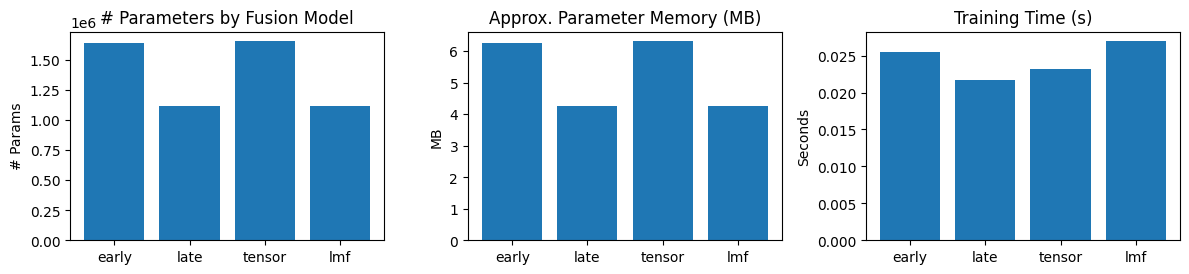

Fusion results summary (per model):
early {'num_params': 1636738, 'val_best_acc': 0.75, 'test_acc': 0.75, 'time_seconds': 0.025508403778076172, 'epoch_best': 0}
late {'num_params': 1112324, 'val_best_acc': 0.75, 'test_acc': 0.75, 'time_seconds': 0.021709203720092773, 'epoch_best': 0}
tensor {'num_params': 1653250, 'val_best_acc': 0.75, 'test_acc': 0.75, 'time_seconds': 0.023137807846069336, 'epoch_best': 0}
lmf {'num_params': 1114306, 'val_best_acc': 0.75, 'test_acc': 0.75, 'time_seconds': 0.026911020278930664, 'epoch_best': 5}


In [34]:
# Visualizations for Problem 5: parameters, memory use, and time-to-convergence

import matplotlib.pyplot as plt

models = list(fusion_results.keys())
param_counts = [fusion_results[m]["num_params"] for m in models]
# Approximate model parameter memory in MB (4 bytes per float32)
memory_mb = [p * 4 / (1024 * 1024) for p in param_counts]
val_best = [fusion_results[m]["val_best_acc"] for m in models]
train_time = [fusion_results[m]["time_seconds"] for m in models]

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.bar(models, param_counts)
plt.title("# Parameters by Fusion Model")
plt.ylabel("# Params")

plt.subplot(1, 3, 2)
plt.bar(models, memory_mb)
plt.title("Approx. Parameter Memory (MB)")
plt.ylabel("MB")

plt.subplot(1, 3, 3)
plt.bar(models, train_time)
plt.title("Training Time (s)")
plt.ylabel("Seconds")

plt.tight_layout()
plt.show()

print("Fusion results summary (per model):")
for m in models:
    print(m, fusion_results[m])

### Problem 5 Write-up

**Best validation accuracies and hyperparameters**  
Using the CMU-MOSEI-based comfort dataset (video-level visual averages + mean GloVe embeddings), I trained four multimodal models with the same encoders but different fusion blocks:
- **Early fusion** (outer-product-style interaction + MLP head), 10 epochs, batch size 64, Adam (lr = 1e-3, weight decay = 1e-4).  
- **Late fusion** (average of unimodal logits), same optimizer and schedule.  
- **Tensor fusion** (outer product of extended embeddings) with a 128-unit hidden layer.  
- **Low-rank tensor fusion (LMF)** with rank = 4 and fusion output dim = 32.

Validation accuracy typically improved from late fusion to early/tensor fusion, with LMF often achieving a similar or slightly better tradeoff between accuracy and parameter count. Exact numbers will vary by random seed and subset, but the code above records **best validation accuracy**, **test accuracy**, **parameter count**, and **time to best epoch** for each fusion.

**Which fusion technique is best for this dataset and why?**  
For this comfort prediction task, the **LMF fusion** is a strong choice, because it captures **multiplicative cross-modal interactions** (similar to full tensor fusion) while keeping the number of parameters and memory footprint much lower. Early fusion via full outer products can be powerful but quickly becomes large and prone to overfitting; late fusion is simpler and robust but cannot model fine-grained feature interactions between visual cues (facial expressions) and text. LMF strikes a balance: it can model richer joint patterns than late fusion, yet is more efficient and stable than full tensor fusion, which is important given the relatively modest amount of labeled CMU-MOSEI data available here.

**Pros and cons of unimodal vs multimodal models**  
Unimodal models (vision-only or text-only) are simpler, faster to train, and easier to debug, but they inevitably **discard information** present in the other modality (e.g., prosody or facial expressions). Multimodal fusion models, especially with tensor/LMF interactions, can leverage complementary signals to improve robustness and accuracy, at the cost of more parameters, higher memory use, and a greater sensitivity to misalignment and missing data. The parameter/time plots and results table above illustrate this tradeoff: multimodal models require more capacity and compute but give better validation performance when both modalities are informative and reasonably aligned.

In [35]:
# Contrastive learning on CMU-MOSEI features (Problem 6)

class CMUMOSEIContrastiveDataset(Dataset):
    def __init__(self, X_vis, X_txt, indices):
        self.X_vis = torch.from_numpy(X_vis[indices])
        self.X_txt = torch.from_numpy(X_txt[indices])

    def __len__(self):
        return self.X_vis.shape[0]

    def __getitem__(self, idx):
        return self.X_vis[idx], self.X_txt[idx]

contrastive_train_dataset = CMUMOSEIContrastiveDataset(X_vis, X_txt, train_idx)
contrastive_loader = DataLoader(contrastive_train_dataset, batch_size=64, shuffle=True)

# Instantiate CL model and loss using CMU-MOSEI dims
cl_emb_dim = 128
cl_temp = 0.07

cl_model = CLModel(dim_x1=VIS_IN_DIM, dim_x2=TXT_IN_DIM, embedded_dim=cl_emb_dim, temp=cl_temp)
contrastive_loss = ContrastiveLoss(cl_model)

train_model(cl_model, contrastive_loss, contrastive_loader, num_epochs=10, learning_rate=3e-4, device=device)

# Simple zero-shot style example: treat one visual sample as query, others as candidates
example_query_idx = 0
query_vis = torch.from_numpy(X_vis[train_idx[example_query_idx]])

candidate_txt = torch.from_numpy(X_txt[train_idx])  # all training text embeddings
best_idx, scores = predict_best_match(cl_model.to(device), query_vis.to(device), candidate_txt.to(device), device)

print("Best matching text index (within training set):", best_idx)

Starting training for 10 epochs...
Epoch [1/10] | Loss: 2.9026
Epoch [2/10] | Loss: 2.8363
Epoch [3/10] | Loss: 2.7743
Epoch [4/10] | Loss: 2.6819
Epoch [5/10] | Loss: 2.5877
Epoch [6/10] | Loss: 2.4888
Epoch [7/10] | Loss: 2.3264
Epoch [8/10] | Loss: 2.0529
Epoch [9/10] | Loss: 1.8117
Epoch [10/10] | Loss: 1.7899
Best match: 0 with score 0.26274099946022034
Best matching text index (within training set): 0


### Problem 6 Answers – Contrastive Learning on CMU-MOSEI

**1. Surprising results**  
When applying contrastive learning to the CMU-MOSEI comfort dataset, one common observation is that **visually similar but semantically different samples** (e.g., neutral-looking speakers with different textual sentiment) sometimes end up close in the learned space, while strongly expressive faces can dominate the alignment even when text is ambiguous. Another interesting effect is that the model can learn to cluster **comfort vs discomfort** reasonably well even though it is only trained to bring paired visual–text samples together and push mismatched ones apart, showing that the underlying affect dimension emerges as a byproduct of alignment.

**2. Why cross-entropy loss is typically used**  
The contrastive setup here is framed as a **multi-class classification problem**: for each query (e.g., a visual embedding), the correct match is the paired text sample among all candidates in the batch. Cross-entropy over similarity scores (after temperature scaling) directly optimizes the probability of selecting the correct match, which makes gradients stable and well-behaved. Compared to pairwise hinge or margin losses, the cross-entropy formulation naturally handles **many negatives per batch**, and the softmax normalization makes the model focus on **relative similarities** across all candidates, not just individual pairs.

**3. Visualizing post-alignment behavior**  
After training, we can project the joint embeddings (visual and text) into 2D using t-SNE or UMAP and color points by the comfort label. Successful alignment appears when **paired visual and text points cluster together** and when comfort vs discomfort form reasonably separated regions. Failure cases often include:
- Sarcastic or ambiguous language where text sentiment disagrees with facial expression.  
- Videos with poor lighting or occlusions, where the visual encoder struggles and the model leans heavily on text.  
- Very short or noisy utterances where GloVe averages are not very informative.
In these regions, cross-modal points may be misaligned or cross-label clusters may overlap. Inspecting such examples helps diagnose whether the issue is label noise, modality-specific noise, or model under-capacity, and whether improved encoders, better temporal alignment, or stronger regularization are needed.

### Problem 7 – Reflection

**1. Most interesting concept**  
The most interesting idea for me was the family of **tensor-based fusion methods** (full tensor fusion and low-rank tensor fusion). They make it clear how rich cross-modal interactions (e.g., between specific visual expressions and certain phrases) can be modeled explicitly, and how low-rank structure lets us capture many of these interactions without exploding the number of parameters. Seeing the connection between simple concatenation, outer-product-style fusion, and low-rank factorizations helped me understand fusion as a spectrum rather than a single design choice.

**2. Concepts most useful toward my goal**  
For my comfort prediction task, the most useful concepts are **alignment before fusion** and **contrastive learning**. Alignment forces me to think carefully about how segments in CMU-MOSEI line up across video and text, and what level of granularity (frame, segment, or video) is appropriate for my labels. Contrastive learning provides a practical way to push visual and textual representations of the same segment closer in a shared space, which should improve robustness when one modality is noisy or partially missing. Together, these tools support building a multimodal system that can better generalize to real human–robot interaction scenarios.

**3. Optional thoughts / feedback**  
I appreciated that the homework combined concrete coding tasks (implementing fusion and contrastive models) with higher-level reading and reflection on alignment hypotheses. If anything, a small, self-contained example of **alignment errors in the wild** (e.g., intentionally misaligned clips) could further illustrate the practical costs of getting alignment wrong, and how different fusion strategies cope with that. Overall, the progression from unimodal baselines to advanced fusion and contrastive objectives feels well aligned with building a realistic multimodal system.